# In-silico perturbation with CellOracle (`backend='cell_oracle'`)

Reproduce the published CellOracle Paul15 *Gata1*-KO benchmark
([Kamimoto *et al.* 2023 *Nature*](https://www.nature.com/articles/s41586-022-05688-9)
Fig. 2-3) through the unified `ov.single.perturb` API.

In [1]:
%matplotlib inline
import omicverse as ov
ov.plot_set(font_path='Arial')

import celloracle as co
import matplotlib.pyplot as plt

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the official Paul15 dataset + scATAC base GRN

In [2]:
adata = co.data.load_Paul2015_data()
base_grn = co.data.load_mouse_scATAC_atlas_base_GRN()
adata

AnnData object with n_obs × n_vars = 2671 × 1999
    obs: 'paul15_clusters', 'n_counts_all', 'n_counts', 'louvain', 'cell_type', 'louvain_annot', 'dpt_pseudotime'
    var: 'n_counts'
    uns: 'cell_type_colors', 'diffmap_evals', 'draw_graph', 'iroot', 'louvain', 'louvain_annot_colors', 'louvain_colors', 'louvain_sizes', 'neighbors', 'paga', 'paul15_clusters_colors', 'pca'
    obsm: 'X_diffmap', 'X_draw_graph_fa', 'X_pca'
    varm: 'PCs'
    layers: 'raw_count'
    obsp: 'connectivities', 'distances'

In [3]:
# Normalize from raw counts + select HVGs (one omicverse call)
adata.X = adata.layers['raw_count'].copy()
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=3000,
                         organism='mouse')

🔍 [2026-05-25 18:46:45] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 1999/1999 genes are kept.
    Among 1999 genes, 1999 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Prg2']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,671 cells × 1,999 genes
   ✓ Runtime: 0.04s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 1,999 highly variable genes out of 1,999 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.59 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

In [4]:
# Force-keep canonical hematopoietic TFs even if they're not in the HVG set
KEEP = ['Gata1','Klf1','Spi1','Gata2','Cebpa','Tal1','Runx1',
        'Hbb-bt','Hbb-bs','Hba-a1','Hba-a2','Alas2','Gypa',
        'Slc4a1','Epor','Mpo','Lyz2','Elane']
mask = adata.var['highly_variable'].copy()
for g in KEEP:
    if g in adata.var_names: mask[g] = True
adata = adata[:, mask].copy()
adata.obsm['X_umap'] = adata.obsm['X_draw_graph_fa'][:, :2].copy()
adata.obs['main_cluster'] = (adata.obs['louvain_annot'].astype(str)
                             .str.split('_').str[0])

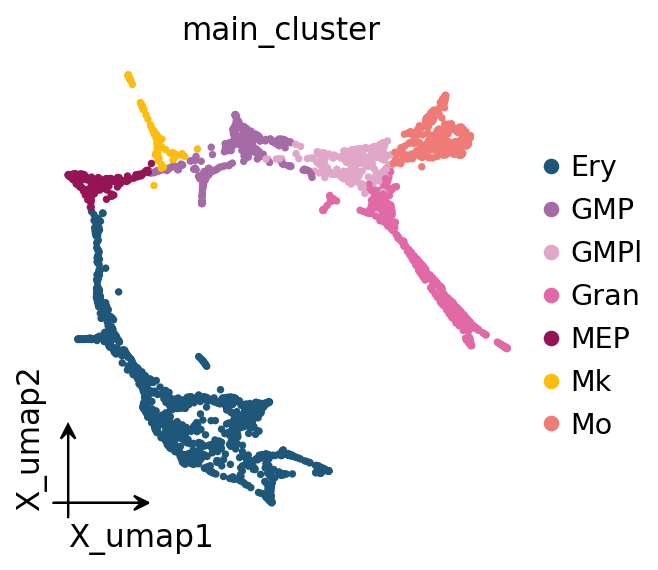

In [5]:
ov.pl.embedding(adata, basis='X_umap', color='main_cluster',
                frameon='small', show=False)
plt.gcf()

## 2. Lineage-specific pseudotime — CellOracle's official recipe

The bundled `dpt_pseudotime` is one global DPT and puts only Ery at
the high-pt end. For the PS analysis we need a pseudotime that's
monotonic along **both** branches (ME = Ery / MEP / Mk and GM = GMP /
GMPl / Gran / Mo). `ov.single.lineage_pseudotime` wraps CellOracle's
`Pseudotime_calculator` so this is one call.

In [6]:
ov.single.lineage_pseudotime(
    adata,
    lineage_dictionary={
        'Lineage_ME': ['Ery_0','Ery_1','Ery_2','Ery_3','Ery_4','Ery_5',
                       'Ery_6','Ery_7','Ery_8','Ery_9','MEP_0','Mk_0'],
        'Lineage_GM': ['GMP_0','GMP_1','GMP_2','GMPl_0','GMPl_1','Gran_0',
                       'Gran_1','Gran_2','Gran_3','Mo_0','Mo_1','Mo_2'],
    },
    root_cells={'Lineage_ME': '1539', 'Lineage_GM': '2244'},
    obsm_key='X_draw_graph_fa',
    cluster_column_name='louvain_annot',
)

AnnData object with n_obs × n_vars = 2671 × 1999
    obs: 'paul15_clusters', 'n_counts_all', 'n_counts', 'louvain', 'cell_type', 'louvain_annot', 'dpt_pseudotime', 'main_cluster', 'Pseudotime'
    var: 'n_counts', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'cell_type_colors', 'diffmap_evals', 'draw_graph', 'iroot', 'louvain', 'louvain_annot_colors', 'louvain_colors', 'louvain_sizes', 'neighbors', 'paga', 'paul15_clusters_colors', 'pca', 'history_log', 'log1p', 'hvg', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'main_cluster_colors_rgba', 'main_cluster_colors'
    obsm: 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_count', 'counts'
    obsp: 'connectivities', 'distances'

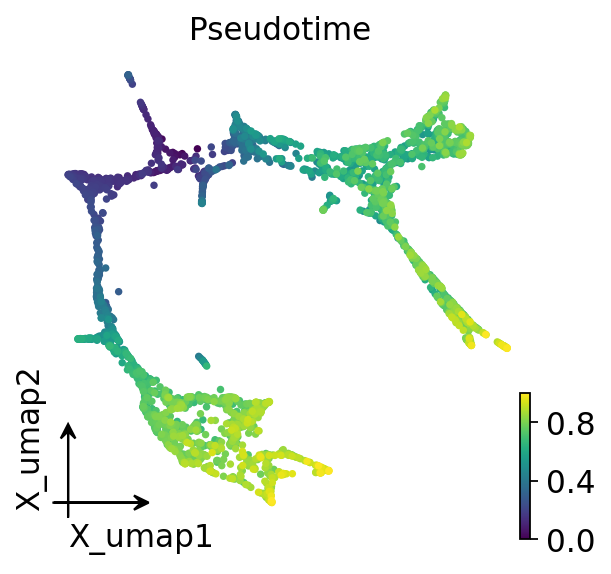

In [7]:
ov.pl.embedding(adata, basis='X_umap', color='Pseudotime',
                cmap='viridis', frameon='small', show=False)
plt.gcf()

## 3. Run the perturbation

`ov.single.perturb(..., backend='cell_oracle')` propagates the
Gata1 KO through the base GRN, runs CellOracle's
`simulate_shift` + `calculate_embedding_shift`, and returns a
`PerturbResult` with everything the downstream methods need.

In [8]:
result = ov.single.perturb(
    adata,
    target='Gata1', mode='ko',
    backend='cell_oracle',
    grn_base=base_grn, n_propagation=3,
    backend_kwargs={'cluster_column_name': 'louvain_annot',
                    'embedding_name': 'X_umap'},
)
result.summary(top_n=10)

  0%|          | 0/24 [00:00<?, ?it/s]

[ov.single.perturb] target='Gata1' mode='ko' backend='cell_oracle'  — top 10 downstream genes by |Δexpr|:
   gene  mean_base  mean_pert     delta    log2_fc
  Gata1   2.566240   0.000000 -2.566240 -21.291225
  Ap2a2   1.909285   1.262324 -0.646961  -0.596950
Slc19a1   2.246588   1.610512 -0.636076  -0.480216
   Ctse   2.102368   1.480923 -0.621445  -0.505518
 Elavl1   2.456314   1.856095 -0.600219  -0.404224
  Ube2c   2.780668   2.210099 -0.570568  -0.331320
  Bola3   2.882679   2.318451 -0.564228  -0.314249
Snrnp40   2.849089   2.288974 -0.560114  -0.315799
   Aqp1   3.192047   2.644143 -0.547904  -0.271681
  Mrto4   3.136276   2.590842 -0.545433  -0.275631


,gene,mean_base,mean_pert,delta,log2_fc
739,Gata1,2.566240,0.000000,-2.566240,-21.291225
175,Ap2a2,1.909285,1.262324,-0.646961,-0.596950
1656,Slc19a1,2.246588,1.610512,-0.636076,-0.480216
481,Ctse,2.102368,1.480923,-0.621445,-0.505518
603,Elavl1,2.456314,1.856095,-0.600219,-0.404224
1907,Ube2c,2.780668,2.210099,-0.570568,-0.331320
271,Bola3,2.882679,2.318451,-0.564228,-0.314249
1699,Snrnp40,2.849089,2.288974,-0.560114,-0.315799
180,Aqp1,3.192047,2.644143,-0.547904,-0.271681
1152,Mrto4,3.136276,2.590842,-0.545433,-0.275631


## 4. Save / load — don't re-run the GRN every time

CellOracle's GRN fit + simulation takes minutes. Persist the full
`PerturbResult` (delta_X, trajectory_shift, perturbed AnnData, GRN,
delta tables) to disk so downstream notebooks resume from a cache.

In [9]:
result.save('/tmp/gata1_ko_paul15.pkl')
result = ov.single.PerturbResult.load('/tmp/gata1_ko_paul15.pkl')

💾 Save Operation:
   Target path: /tmp/gata1_ko_paul15.pkl
   Object type: PerturbResult
   Using: pickle


   ✅ Successfully saved!
────────────────────────────────────────────────────────────
📂 Load Operation:
   Source path: /tmp/gata1_ko_paul15.pkl
   Using: pickle


   ✅ Successfully loaded!
   Loaded object type: PerturbResult
────────────────────────────────────────────────────────────


## 5. CellOracle's official 6-panel layout

`ov.pl.perturb_celloracle_layout` calls CellOracle's own
`Oracle_development_module.visualize_development_module_layout_0` —
**1:1** with the published Gata1-KO Paul15 figure. The function works
on both `cell_oracle` and `sctenifoldknk` backends.

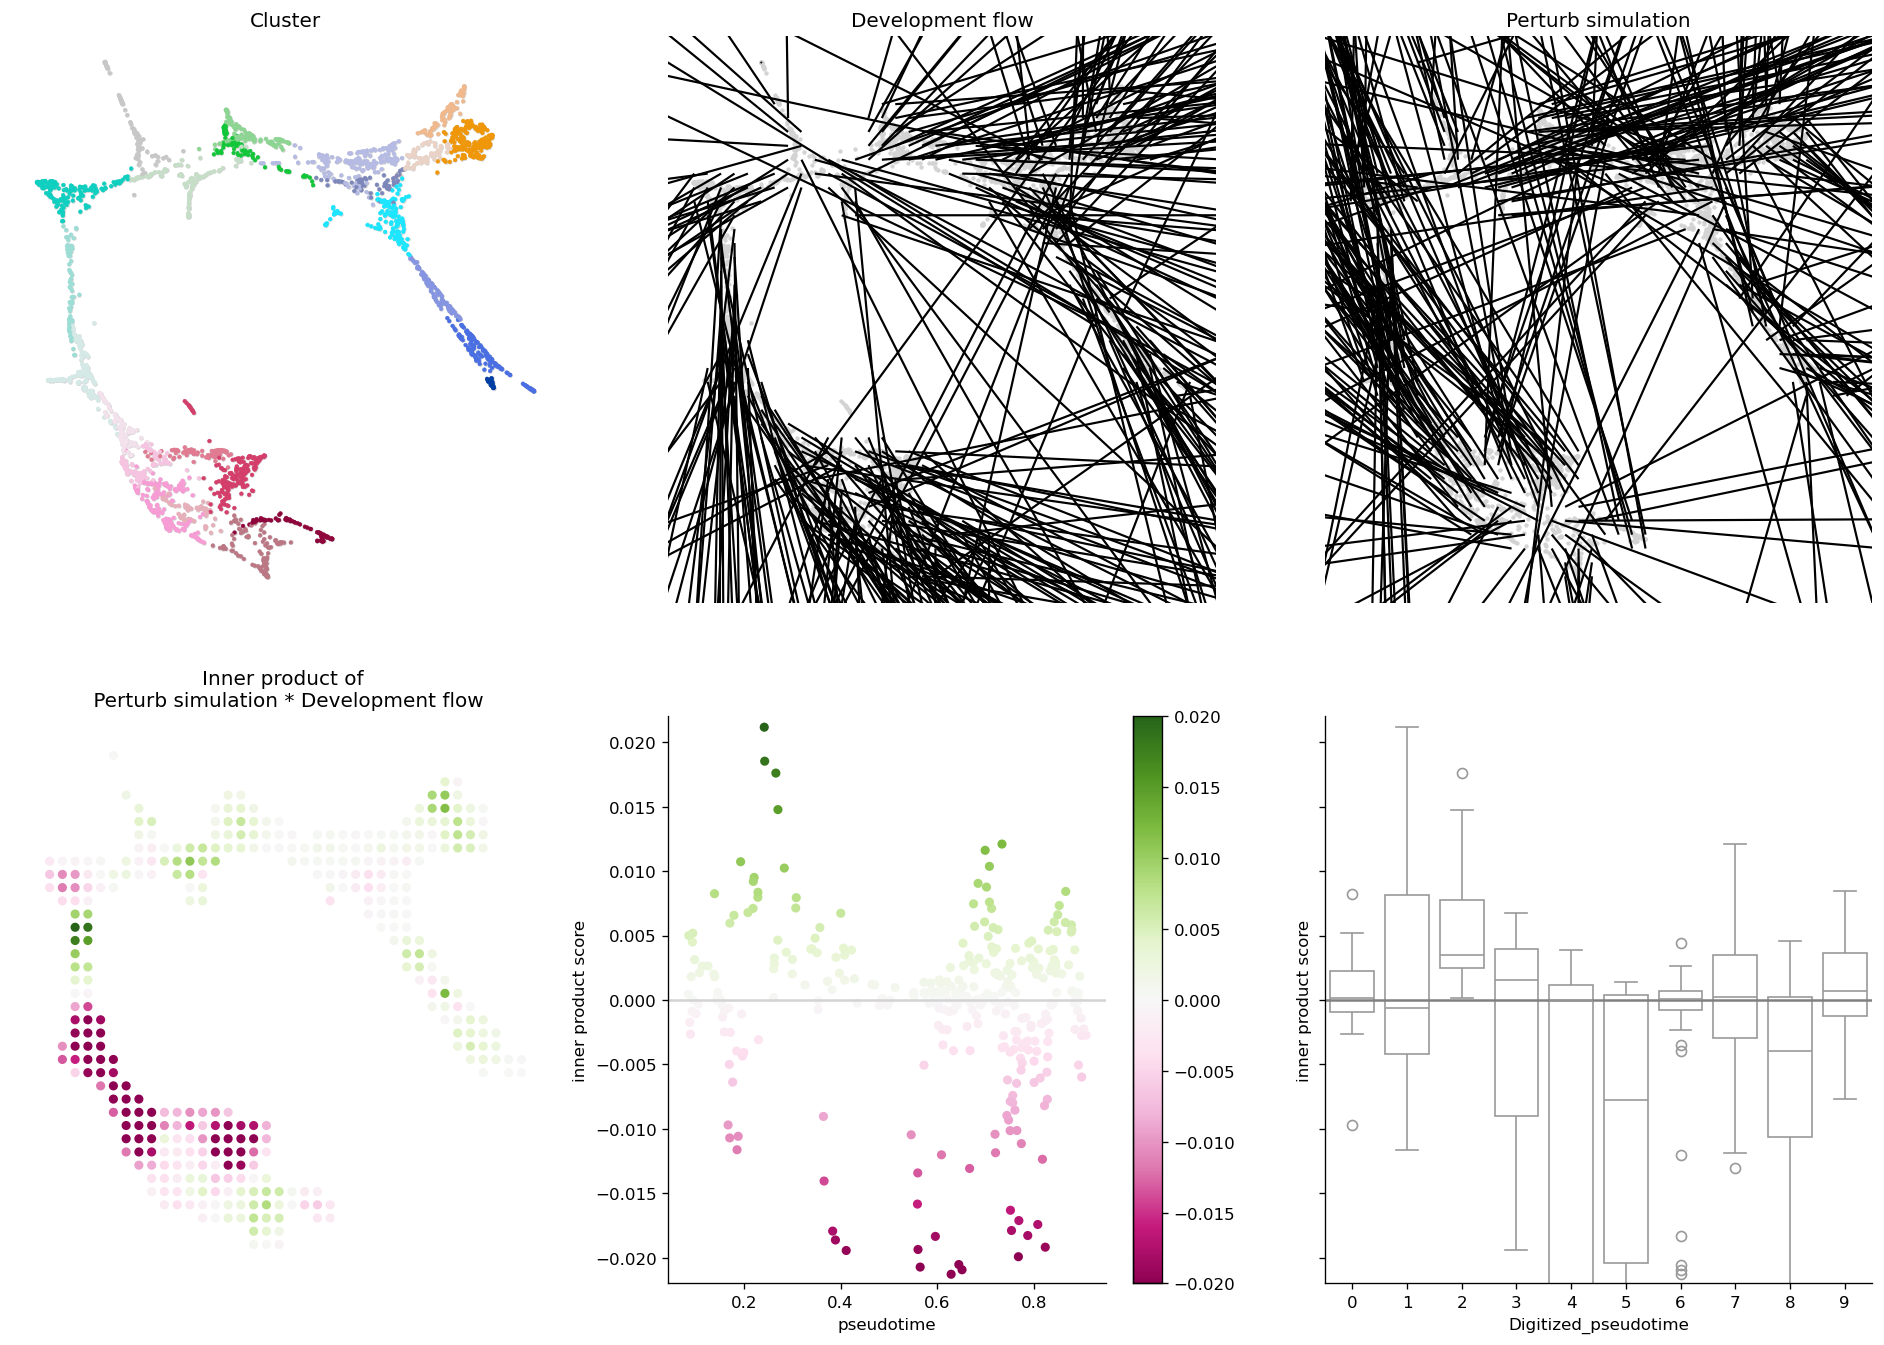

In [10]:
fig, _ = ov.pl.perturb_celloracle_layout(
    adata, result,
    pseudotime_key='Pseudotime',
    cluster_column_name='louvain_annot',
    vm=0.02,
)
fig

## 6. Cluster-level transition matrix + Sankey

In [11]:
result.cluster_transitions(adata=adata, cluster_col='main_cluster').round(3)

,Ery,GMP,GMPl,Gran,MEP,Mk,Mo
Ery,0.996,0.000,0.000,0.000,0.004,0.000,0.000
GMP,0.000,0.902,0.046,0.003,0.010,0.039,0.000
GMPl,0.000,0.065,0.826,0.059,0.000,0.000,0.050
Gran,0.000,0.004,0.106,0.885,0.000,0.000,0.005
MEP,0.031,0.052,0.000,0.000,0.890,0.028,0.000
Mk,0.000,0.257,0.000,0.000,0.133,0.610,0.000
Mo,0.000,0.000,0.039,0.005,0.000,0.000,0.955


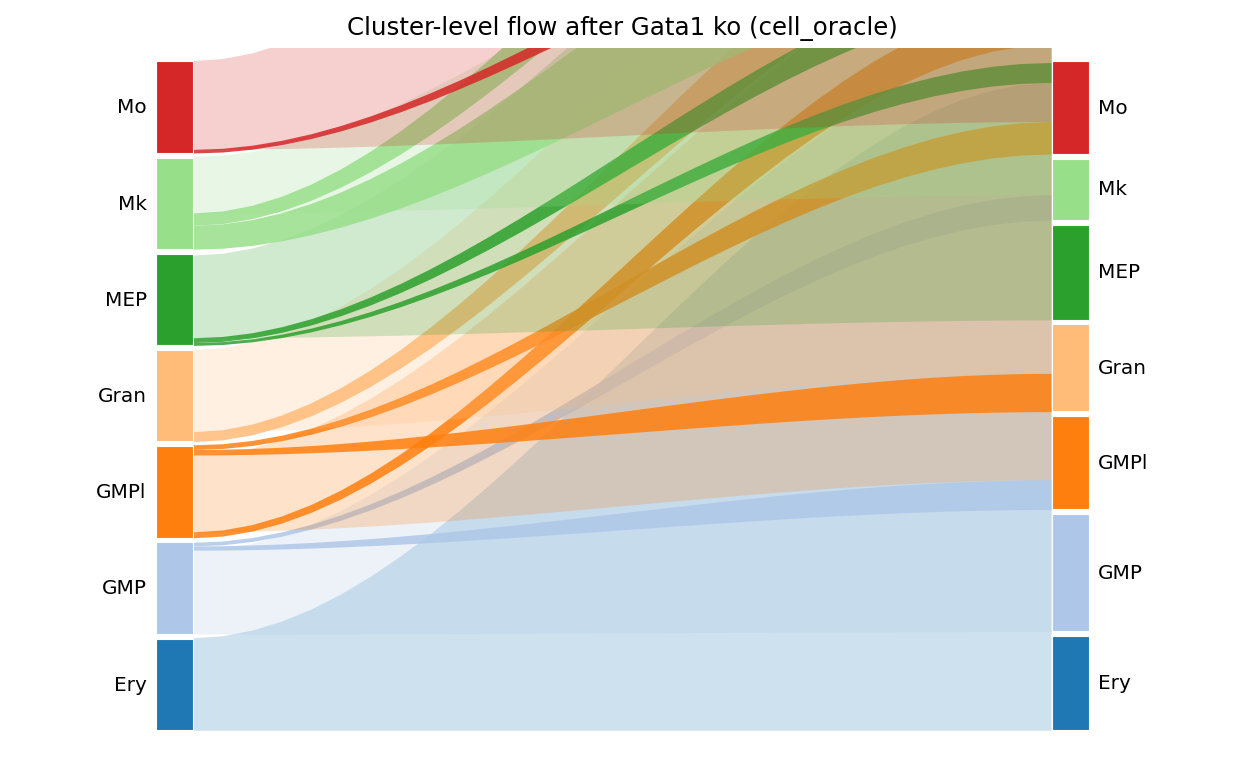

In [12]:
fig, _ = ov.pl.perturb_sankey(result, adata=adata,
                              cluster_col='main_cluster', min_flow=0.03)
fig

## 7. Markov-walk endpoints from MEP cells

Where do MEP cells end up after 15 steps of the post-KO transition
matrix? The canonical CellOracle finding is **Mk → GMP** redirect.

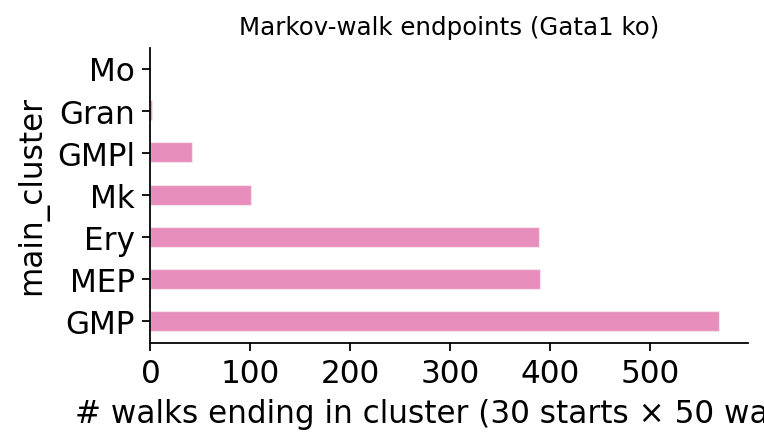

In [13]:
mep_cells = adata.obs_names[adata.obs['main_cluster'] == 'MEP'][:30]
fig, _ = ov.pl.perturb_markov_endpoints(
    result, adata=adata,
    start_cells=list(mep_cells),
    cluster_col='main_cluster',
    n_steps=15, n_walks_per_cell=50,
)
fig

## 8. Per-gene significance + volcano

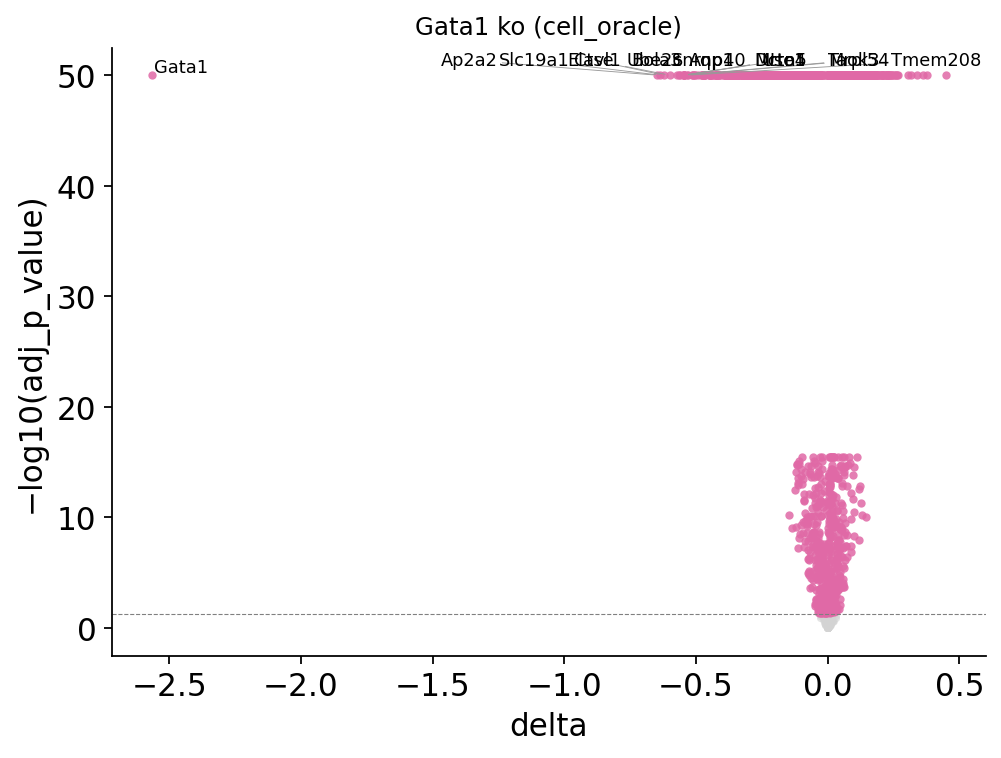

In [14]:
result.add_significance(adata=adata, n_perms=100)
fig, _ = ov.pl.perturb_volcano(result, top_n=15)
fig

## 9. Pathway + phenotype enrichment

The MGI mammalian-phenotype hits are the canonical *Gata1* KO
phenotypes — *Abnormal Embryonic Erythropoiesis*, *Abnormal
Megakaryocyte Differentiation*, *Increased Neutrophil Cell Number*.

In [15]:
mgi = result.phenotype_enrichment(
    top_n=200,
    db='MGI_Mammalian_Phenotype_Level_4_2024',
    organism='mouse',
)
mgi.sort_values('Adjusted P-value').head(10)[
    ['Term', 'Adjusted P-value', 'Combined Score']
]

,Term,Adjusted P-value,Combined Score
0,Decreased Hematocrit MP:0000208,0.018829,54.246440
1,"Preweaning Lethality, Complete Penetrance MP:0...",0.035193,21.254706
2,Abnormal Embryonic Erythropoiesis MP:0004229,0.085172,130.937480
3,Decreased Eosinophil Cell Number MP:0005012,0.090484,75.832323
4,Abnormal Megakaryocyte Differentiation MP:0000229,0.142312,159.519160
5,Abnormal Respiratory Electron Transport Chain ...,0.144431,78.646136
6,Small Thymus MP:0000706,0.186198,37.681946
7,Thymus Cortex Atrophy MP:0013585,0.214038,326.620610
8,Polyploidy MP:0004025,0.223515,91.402614
9,Abnormal Leukocyte Cell Number MP:0000217,0.250162,80.359050


## 10. Overall robustness — sign-flip null on Δ-X

In [16]:
result.permutation_test(adata=adata, n_perms=100)

{'Z_obs': 11.399013254976625,
 'Z_mean_null': 0.7375057132390335,
 'Z_std_null': 0.1393375765751764,
 'p_value': 0.009900990099009901}

## Summary

| Step | API |
|---|---|
| Lineage-specific pseudotime | `ov.single.lineage_pseudotime` |
| Run perturbation | `ov.single.perturb(backend='cell_oracle')` |
| Save / load | `result.save(path)` / `ov.single.PerturbResult.load(path)` |
| 6-panel CellOracle figure | `ov.pl.perturb_celloracle_layout` |
| Cluster transitions Sankey | `ov.pl.perturb_sankey` |
| Markov endpoints | `ov.pl.perturb_markov_endpoints` |
| Volcano + significance | `result.add_significance` + `ov.pl.perturb_volcano` |
| Phenotype enrichment | `result.phenotype_enrichment` |
| Robustness | `result.permutation_test` |

## References

- Kamimoto, K. *et al.* **Dissecting cell identity via network
  inference and in silico gene perturbation.** *Nature* 614 (2023).
- Paul, F. *et al.* **Transcriptional Heterogeneity and Lineage
  Commitment in Myeloid Progenitors.** *Cell* 163 (2015).
- omicverse issue
  [#739](https://github.com/omicverse/omicverse/issues/739) motivated
  this module.